# CNN Fundamentals: MNIST, Fashion-MNIST, and CIFAR-10

This notebook introduces convolutional neural networks through dense baselines, manual
forward-pass verification, and CNN experiments on MNIST, Fashion-MNIST, and CIFAR-10.
It concludes with a CIFAR-10 feature-order study that illustrates why spatial structure matters.

## Dense and CNN Baselines Across Benchmark Image Datasets

### Dense-to-CNN Baselines with Keras and TensorFlow

We will be using the Keras library which provides a Python interface for artificial neural networks.

The general guide is at :
https://keras.io/guides/

We will focus on the Sequential model, described here: https://keras.io/guides/sequential_model/

Import libraries

In [4]:
import tensorflow as tf
import numpy as np
import os

import matplotlib.pyplot as plt

from keras.models import Model

from tensorflow.keras.layers import *
from tensorflow.keras.activations import *

from keras.utils import plot_model

Dense Model Definition

In [8]:
def dense_model(inputs = 784,hidden_1=500, hidden_2=500):
  model = tf.keras.models.Sequential()
  model.add(Dense(hidden_1, input_shape=(inputs,), activation='relu'))
  model.add(Dense(hidden_2, activation='relu'))
  model.add(Dense(10, activation='softmax'))
  return model

Build and compile model

In [9]:
dense_network = dense_model()
dense_network.summary()
dense_network.compile(loss="categorical_crossentropy", metrics=["accuracy"])
all_history = []

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 500)            │       392,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 500)            │       250,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         5,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 648,010 (2.47 MB)

 Trainable params: 648,010 (2.47 MB)

 Non-trainable params: 0 (0.00 B)

Display model

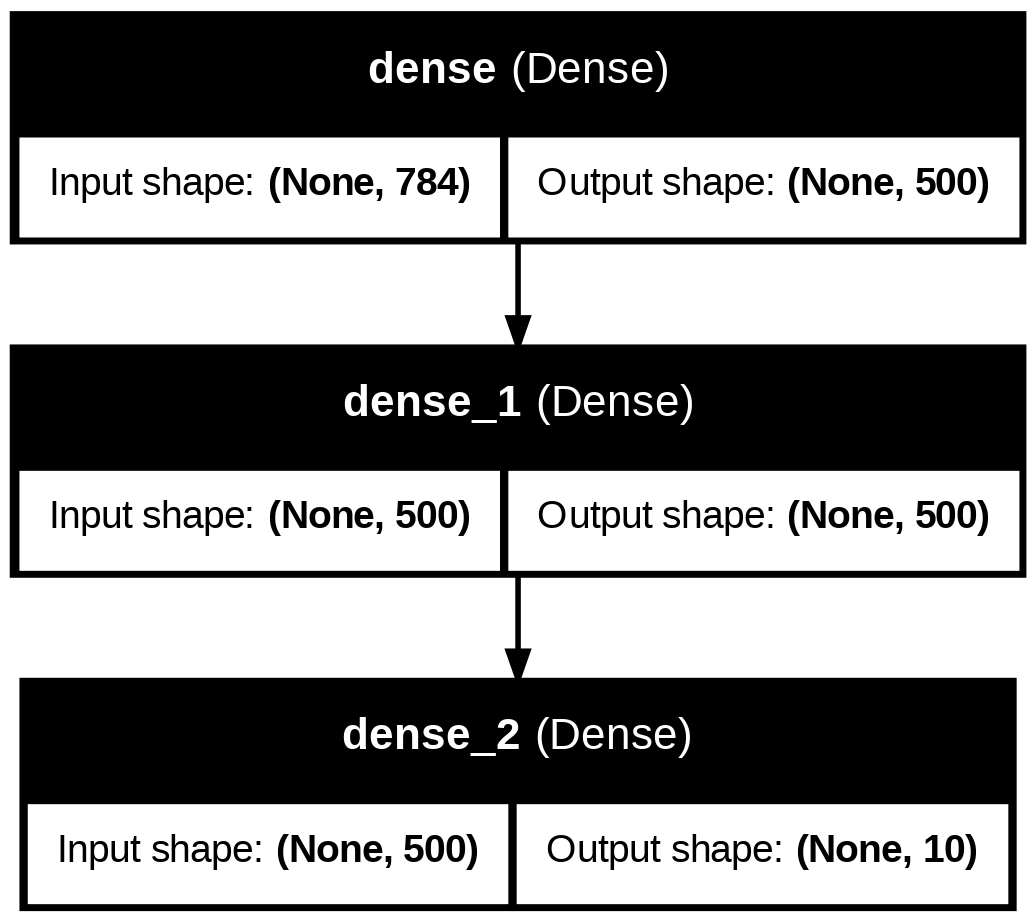

In [10]:
plot_model(dense_network, show_shapes=True, show_layer_names=True)

## MNIST Evaluation

In [7]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
x_train = np.float32(x_train/255).reshape(x_train.shape[0],-1)
x_test = np.float32(x_test/255).reshape(x_test.shape[0],-1)

# Convert y to one-hot
y_train = tf.keras.utils.to_categorical(y_train, 10)
y_test = tf.keras.utils.to_categorical(y_test, 10)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Train model

In [12]:
history = dense_network.fit(
    x_train, y_train,
    epochs =  20,
    batch_size=256,
    verbose = 1,
    validation_data=(x_test, y_test),
)

all_history.append(history)

print('Final accuracy on training set: {:.4f}'.format(history.history['accuracy'][-1]))
print('Final accuracy on test set: {:.4f}'.format(history.history['val_accuracy'][-1]))

Epoch 1/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 8s 30ms/step - accuracy: 0.9120 - loss: 0.2903 - val_accuracy: 0.9397 - val_loss: 0.1956
Epoch 2/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 8s 35ms/step - accuracy: 0.9691 - loss: 0.1015 - val_accuracy: 0.9671 - val_loss: 0.1032
Epoch 3/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 8s 32ms/step - accuracy: 0.9795 - loss: 0.0646 - val_accuracy: 0.9754 - val_loss: 0.0725
Epoch 4/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 9s 27ms/step - accuracy: 0.9855 - loss: 0.0451 - val_accuracy: 0.9746 - val_loss: 0.0848
Epoch 5/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 11s 30ms/step - accuracy: 0.9905 - loss: 0.0312 - val_accuracy: 0.9801 - val_loss: 0.0655
Epoch 6/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 32ms/step - accuracy: 0.9924 - loss: 0.0235 - val_accuracy: 0.9782 - val_loss: 0.0718
Epoch 7/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.9945 - loss: 0.0172 - val_accuracy: 0.9753 - val_loss: 0.0955
Epoch 8/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 8s 33ms/step - accuracy: 0.9962 - loss: 0.0124 - val_acc

Plot Results

In [13]:
def plot_results(all_history):
  loss, val_loss, accuracy, val_accuracy = [], [], [], []
  for history in all_history:
    loss += history.history['loss']
    val_loss += history.history['val_loss']
    accuracy += history.history['accuracy']
    val_accuracy += history.history['val_accuracy']

  fig, ax = plt.subplots()
  ax.plot(accuracy,label = 'train')
  ax.plot(val_accuracy,label = 'test')
  ax.set_title('Accuracy')
  ax.legend(loc='lower right')
  fig, ax = plt.subplots()
  ax.plot(loss,label = 'train')
  ax.plot(val_loss,label = 'test')
  ax.set_title('Loss')
  ax.legend(loc='upper right')

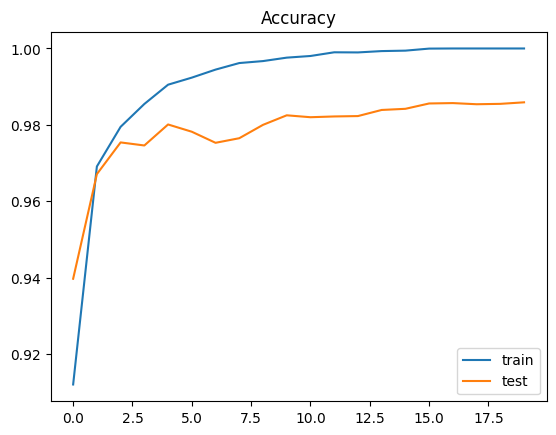

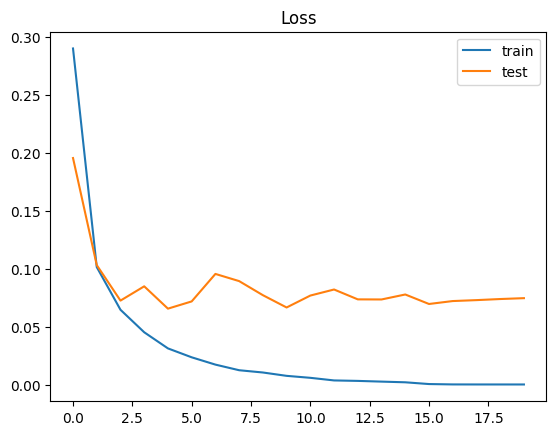

In [14]:
plot_results(all_history)

## Fashion-MNIST Evaluation

In [15]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()
x_train = np.float32(x_train/255).reshape(x_train.shape[0],-1)
x_test = np.float32(x_test/255).reshape(x_test.shape[0],-1)

# Convert y to one-hot
y_train = tf.keras.utils.to_categorical(y_train, 10)
y_test = tf.keras.utils.to_categorical(y_test, 10)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [16]:
dense_network = dense_model()
dense_network.summary()
dense_network.compile(loss="categorical_crossentropy", metrics=["accuracy"])
all_history = []

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 500)            │       392,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 500)            │       250,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         5,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 648,010 (2.47 MB)

 Trainable params: 648,010 (2.47 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 8s 31ms/step - accuracy: 0.7796 - loss: 0.6102 - val_accuracy: 0.8174 - val_loss: 0.5242
Epoch 2/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 31ms/step - accuracy: 0.8501 - loss: 0.4032 - val_accuracy: 0.8021 - val_loss: 0.5738
Epoch 3/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 8s 33ms/step - accuracy: 0.8689 - loss: 0.3540 - val_accuracy: 0.8447 - val_loss: 0.4182
Epoch 4/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 29ms/step - accuracy: 0.8805 - loss: 0.3188 - val_accuracy: 0.7923 - val_loss: 0.5673
Epoch 5/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 8s 33ms/step - accuracy: 0.8885 - loss: 0.2984 - val_accuracy: 0.8437 - val_loss: 0.3955
Epoch 6/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 28ms/step - accuracy: 0.8956 - loss: 0.2794 - val_accuracy: 0.8618 - val_loss: 0.3799
Epoch 7/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 8s 34ms/step - accuracy: 0.8994 - loss: 0.2645 - val_accuracy: 0.8808 - val_loss: 0.3316
Epoch 8/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 10s 41ms/step - accuracy: 0.9040 - loss: 0.2503 - val_acc

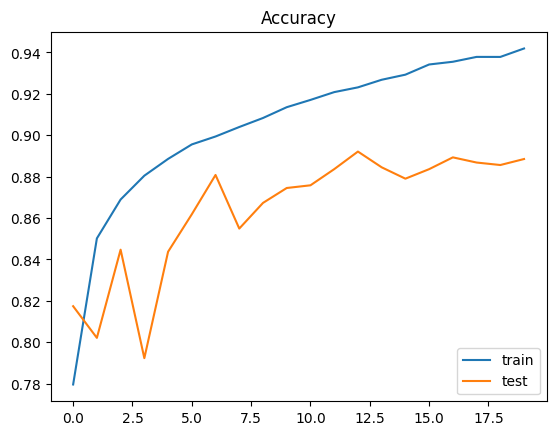

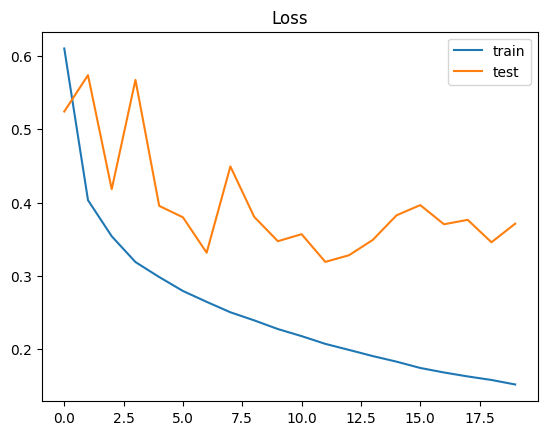

In [17]:
history = dense_network.fit(
    x_train, y_train,
    epochs =  20,
    batch_size=256,
    verbose = 1,
    validation_data=(x_test, y_test),
)

all_history.append(history)

print('Final accuracy on training set: {:.4f}'.format(history.history['accuracy'][-1]))
print('Final accuracy on test set: {:.4f}'.format(history.history['val_accuracy'][-1]))

plot_results(all_history)

## CIFAR-10 Evaluation

In [18]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()
x_train = np.float32(x_train/255).reshape(x_train.shape[0],-1)
x_test = np.float32(x_test/255).reshape(x_test.shape[0],-1)

# Convert y to one-hot
y_train = tf.keras.utils.to_categorical(y_train, num_classes=10)
y_test = tf.keras.utils.to_categorical(y_test, num_classes=10)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2457s 14us/step


In [19]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()
x_train = np.vstack((x_train, x_train[:,::-1]))
y_train = np.vstack((y_train, y_train))

x_train = np.float32(x_train/255).reshape(x_train.shape[0],-1)
x_test = np.float32(x_test/255).reshape(x_test.shape[0],-1)

# Convert y to one-hot
y_train = tf.keras.utils.to_categorical(y_train, num_classes=10)
y_test = tf.keras.utils.to_categorical(y_test, num_classes=10)

Display some images from CIFAR-10

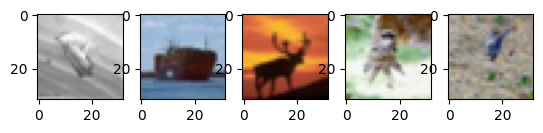

In [20]:
sel = np.random.randint(0,x_train.shape[0],size = 5)
fig, ax = plt.subplots(1,len(sel))
for i,s in enumerate(sel):
  ax[i].imshow(x_train[s].reshape(32,32,3))

In [21]:
dense_network = dense_model(inputs = x_train.shape[1],hidden_1=250, hidden_2=250)
dense_network.summary()
dense_network.compile(loss="categorical_crossentropy", metrics=["accuracy"])
all_history = []

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 250)            │       768,250 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 250)            │        62,750 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │         2,510 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 833,510 (3.18 MB)

 Trainable params: 833,510 (3.18 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 35s 45ms/step - accuracy: 0.5627 - loss: 1.2335 - val_accuracy: 0.4355 - val_loss: 1.8380
Epoch 2/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 19s 25ms/step - accuracy: 0.5658 - loss: 1.2302 - val_accuracy: 0.4103 - val_loss: 2.0625
Epoch 3/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 21s 27ms/step - accuracy: 0.5667 - loss: 1.2257 - val_accuracy: 0.4455 - val_loss: 1.7983
Epoch 4/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 19s 24ms/step - accuracy: 0.5669 - loss: 1.2220 - val_accuracy: 0.4013 - val_loss: 2.3224
Epoch 5/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 19s 25ms/step - accuracy: 0.5673 - loss: 1.2223 - val_accuracy: 0.4352 - val_loss: 1.8611
Epoch 6/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 25s 30ms/step - accuracy: 0.5706 - loss: 1.2190 - val_accuracy: 0.4380 - val_loss: 1.8844
Epoch 7/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 20s 25ms/step - accuracy: 0.5700 - loss: 1.2156 - val_accuracy: 0.4561 - val_loss: 1.7899
Epoch 8/50
782/782 ━━━━━━━━━━━━━━━━━━━━ 21s 26ms/step - accuracy: 0.5704 - loss: 1.2109 - 

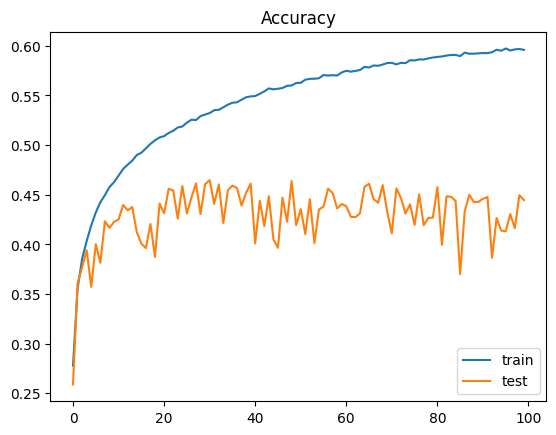

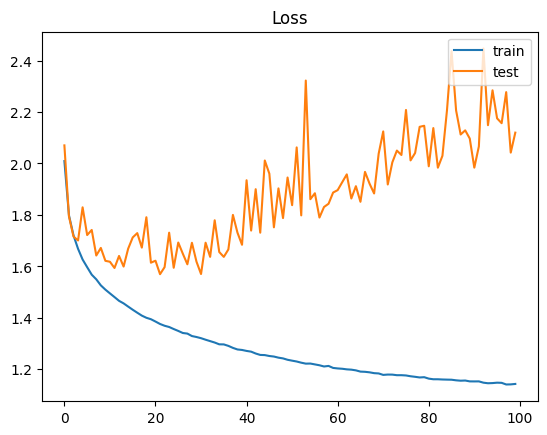

In [24]:
history = dense_network.fit(
    x_train, y_train,
    epochs =  50,
    batch_size=128,
    verbose = 1,
    validation_data=(x_test, y_test),
)

all_history.append(history)

print('Final accuracy on training set: {:.4f}'.format(history.history['accuracy'][-1]))
print('Final accuracy on test set: {:.4f}'.format(history.history['val_accuracy'][-1]))

plot_results(all_history)

### Convolutional Neural Networks with Keras and TensorFlow

In [25]:
def cnn_model(input_shape=(28,28,1)):
  model = tf.keras.models.Sequential()
  model.add(Conv2D(32, kernel_size=(3, 3), input_shape=input_shape, activation="relu"))
  model.add(MaxPooling2D(pool_size=(2, 2)))
  model.add(Conv2D(64, kernel_size=(3, 3), activation="relu"))
  model.add(MaxPooling2D(pool_size=(2, 2)))
  model.add(Flatten())
  model.add(Dense(10, activation='softmax'))
  return model

Build and compile model

In [26]:
cnn = cnn_model()
cnn.summary()
cnn.compile(loss="categorical_crossentropy", metrics=["accuracy"])
all_history = []

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │        16,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,826 (136.04 KB)

 Trainable params: 34,826 (136.04 KB)

 Non-trainable params: 0 (0.00 B)

Display model

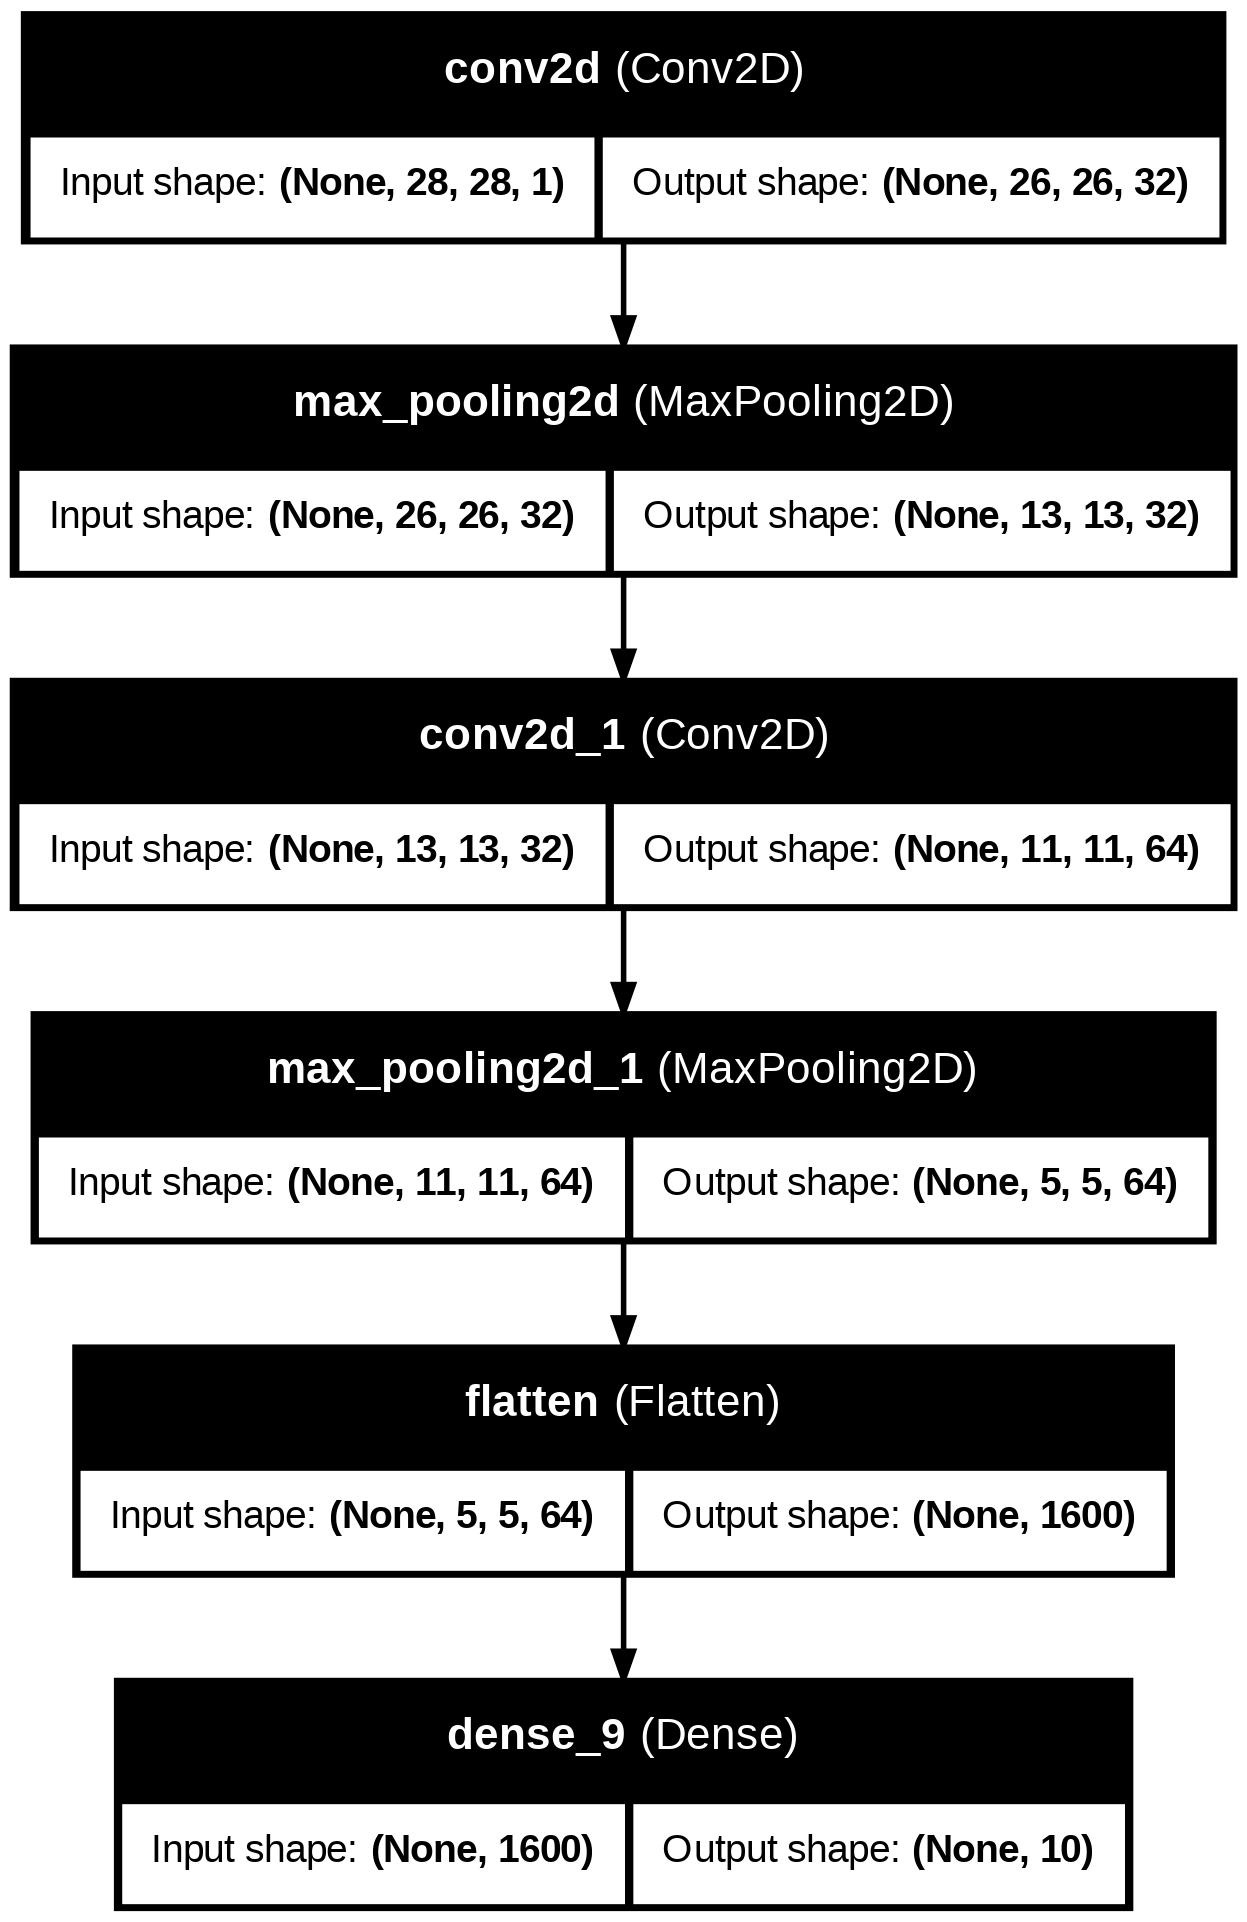

In [27]:
plot_model(cnn, show_shapes=True, show_layer_names=True)

Epoch 1/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 49s 203ms/step - accuracy: 0.8967 - loss: 0.3554 - val_accuracy: 0.9594 - val_loss: 0.1265
Epoch 2/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 50s 213ms/step - accuracy: 0.9689 - loss: 0.1032 - val_accuracy: 0.9637 - val_loss: 0.1085
Epoch 3/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 47s 202ms/step - accuracy: 0.9782 - loss: 0.0726 - val_accuracy: 0.9841 - val_loss: 0.0523
Epoch 4/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 84s 212ms/step - accuracy: 0.9822 - loss: 0.0582 - val_accuracy: 0.9859 - val_loss: 0.0467
Epoch 5/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 81s 208ms/step - accuracy: 0.9848 - loss: 0.0493 - val_accuracy: 0.9866 - val_loss: 0.0412
Epoch 6/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 48s 202ms/step - accuracy: 0.9878 - loss: 0.0417 - val_accuracy: 0.9853 - val_loss: 0.0417
Epoch 7/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 82s 202ms/step - accuracy: 0.9891 - loss: 0.0366 - val_accuracy: 0.9884 - val_loss: 0.0350
Epoch 8/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 83s 205ms/step - accuracy: 0.9902 - loss: 0

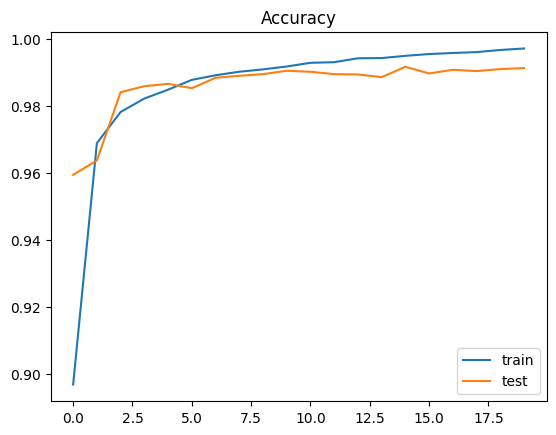

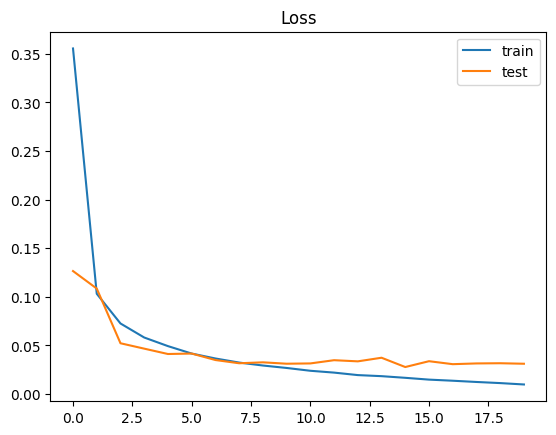

In [28]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
x_train = np.float32(np.expand_dims(x_train, -1)/255)
x_test = np.float32(np.expand_dims(x_test, -1)/255)

# Convert y to one-hot
y_train = tf.keras.utils.to_categorical(y_train, 10)
y_test = tf.keras.utils.to_categorical(y_test, 10)


history = cnn.fit(
    x_train, y_train,
    epochs =  20,
    batch_size=256,
    verbose = 1,
    validation_data=(x_test, y_test),
)

all_history.append(history)

print('Final accuracy on training set: {:.4f}'.format(history.history['accuracy'][-1]))
print('Final accuracy on test set: {:.4f}'.format(history.history['val_accuracy'][-1]))

plot_results(all_history)

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 10)             │        16,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,826 (136.04 KB)

 Trainable params: 34,826 (136.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 51s 213ms/step - accuracy: 0.7442 - loss: 0.7050 - val_accuracy: 0.8022 - val_loss: 0.5727
Epoch 2/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 82s 213ms/step - accuracy: 0.8377 - loss: 0.4481 - val_accuracy: 0.8354 - val_loss: 0.4494
Epoch 3/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 48s 204ms/step - accuracy: 0.8604 - loss: 0.3904 - val_accuracy: 0.8376 - val_loss: 0.4383
Epoch 4/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 88s 228ms/step - accuracy: 0.8727 - loss: 0.3556 - val_accuracy: 0.8566 - val_loss: 0.4018
Epoch 5/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 49s 208ms/step - accuracy: 0.8815 - loss: 0.3302 - val_accuracy: 0.8773 - val_loss: 0.3392
Epoch 6/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 85s 223ms/step - accuracy: 0.8873 - loss: 0.3111 - val_accuracy: 0.8658 - val_loss: 0.3605
Epoch 7/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 81s 219ms/step - accuracy: 0.8931 - loss: 0.2977 - val_accuracy: 0.8808 - val_loss: 0.3294
Epoch 8/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 49s 210ms/step - accuracy: 0.8974 - loss: 0

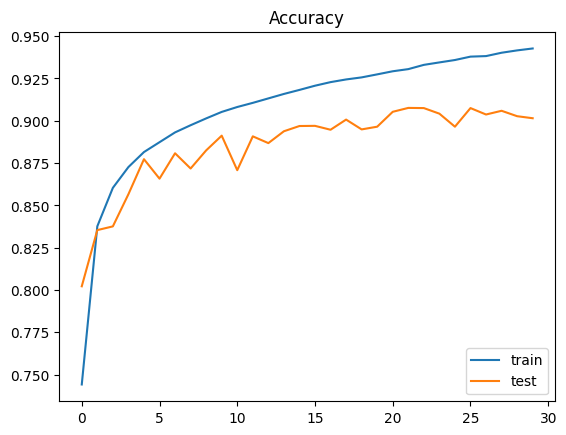

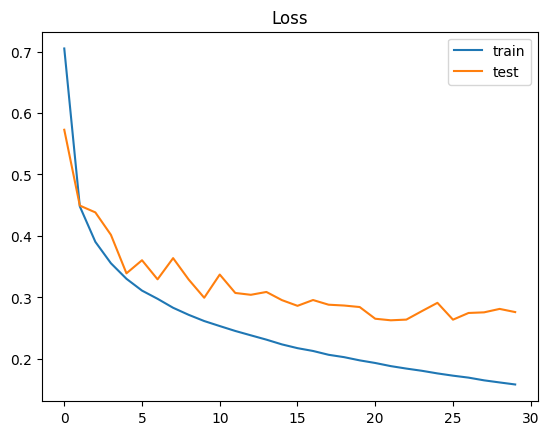

In [29]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()
x_train = np.float32(np.expand_dims(x_train, -1)/255)
x_test = np.float32(np.expand_dims(x_test, -1)/255)

# Convert y to one-hot
y_train = tf.keras.utils.to_categorical(y_train, 10)
y_test = tf.keras.utils.to_categorical(y_test, 10)

cnn = cnn_model()
cnn.summary()
cnn.compile(loss="categorical_crossentropy", metrics=["accuracy"])
all_history = []

history = cnn.fit(
    x_train, y_train,
    epochs =  30,
    batch_size=256,
    verbose = 1,
    validation_data=(x_test, y_test),
)

all_history.append(history)

print('Final accuracy on training set: {:.4f}'.format(history.history['accuracy'][-1]))
print('Final accuracy on test set: {:.4f}'.format(history.history['val_accuracy'][-1]))

plot_results(all_history)

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │        23,050 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 42,442 (165.79 KB)

 Trainable params: 42,442 (165.79 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 68s 342ms/step - accuracy: 0.3357 - loss: 1.8675 - val_accuracy: 0.4018 - val_loss: 1.7268
Epoch 2/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 68s 349ms/step - accuracy: 0.4540 - loss: 1.5529 - val_accuracy: 0.5102 - val_loss: 1.4206
Epoch 3/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 78s 329ms/step - accuracy: 0.5070 - loss: 1.4192 - val_accuracy: 0.5216 - val_loss: 1.3419
Epoch 4/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 81s 323ms/step - accuracy: 0.5390 - loss: 1.3294 - val_accuracy: 0.4999 - val_loss: 1.4198
Epoch 5/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 64s 328ms/step - accuracy: 0.5623 - loss: 1.2607 - val_accuracy: 0.5458 - val_loss: 1.3160
Epoch 6/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 80s 320ms/step - accuracy: 0.5829 - loss: 1.2050 - val_accuracy: 0.5597 - val_loss: 1.2274
Epoch 7/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 64s 325ms/step - accuracy: 0.5990 - loss: 1.1560 - val_accuracy: 0.5838 - val_loss: 1.2213
Epoch 8/30
196/196 ━━━━━━━━━━━━━━━━━━━━ 64s 325ms/step - accuracy: 0.6126 - loss: 1

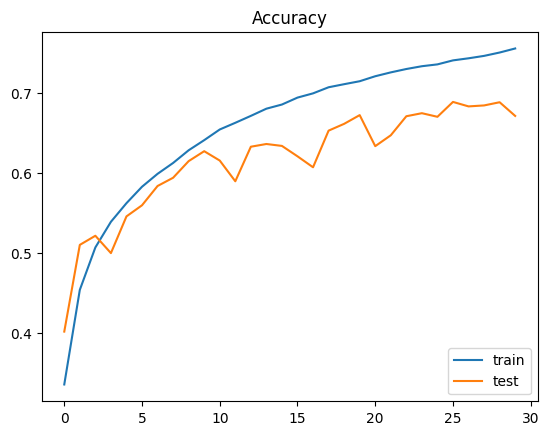

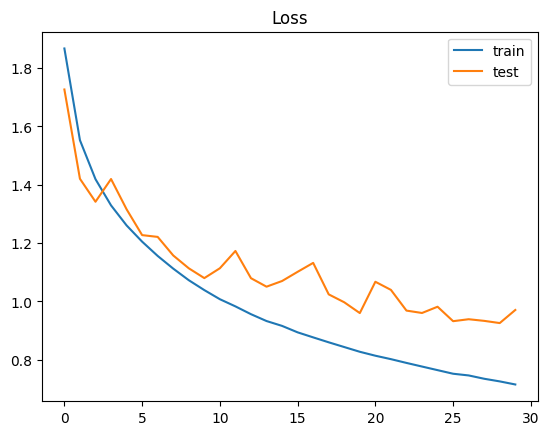

In [30]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()
x_train = np.float32(x_train)/255
x_test = np.float32(x_test)/255

# Convert y to one-hot
y_train = tf.keras.utils.to_categorical(y_train, 10)
y_test = tf.keras.utils.to_categorical(y_test, 10)

cnn = cnn_model(input_shape=(32,32,3))
cnn.summary()
cnn.compile(loss="categorical_crossentropy", metrics=["accuracy"])
all_history = []

history = cnn.fit(
    x_train, y_train,
    epochs =  30,
    batch_size=256,
    verbose = 1,
    validation_data=(x_test, y_test),
)

all_history.append(history)

print('Final accuracy on training set: {:.4f}'.format(history.history['accuracy'][-1]))
print('Final accuracy on test set: {:.4f}'.format(history.history['val_accuracy'][-1]))

plot_results(all_history)

## Manual Forward Pass from Extracted Dense-Network Weights

### Network Assumption

The forward-pass implementation assumes zero or more ReLU layers followed by a softmax output layer.

In [31]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from keras.models import Model
from tensorflow.keras.layers import *
from sklearn.metrics import accuracy_score

In [32]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
x_train = np.float32(x_train/255).reshape(x_train.shape[0],-1)
x_test = np.float32(x_test/255).reshape(x_test.shape[0],-1)

# Convert y to one-hot
y_train = tf.keras.utils.to_categorical(y_train, 10)
y_test = tf.keras.utils.to_categorical(y_test, 10)

In [33]:
def model_3layers():
  model = tf.keras.models.Sequential()
  model.add(Dense(500, input_shape =(784,), activation='relu'))
  model.add(Dense(300, activation='relu'))
  model.add(Dense(10, activation='softmax'))
  return model

model = model_3layers()
model.summary()
model.compile(loss="CategoricalCrossentropy", metrics=["accuracy"])

history = model.fit(
    x_train, y_train,
    epochs = 10,
    batch_size = 100,
    verbose = 2, # Print loss and accuracy after evrey epoch. Set to 0 to see only final results
    validation_data=(x_test, y_test), # If provided, allows to keep track of loss on validation data as traiing progresses
)

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 500)            │       392,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 300)            │       150,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 10)             │         3,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 545,810 (2.08 MB)

 Trainable params: 545,810 (2.08 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
600/600 - 13s - 22ms/step - accuracy: 0.9323 - loss: 0.2227 - val_accuracy: 0.9713 - val_loss: 0.0895
Epoch 2/10
600/600 - 11s - 18ms/step - accuracy: 0.9756 - loss: 0.0818 - val_accuracy: 0.9750 - val_loss: 0.0778
Epoch 3/10
600/600 - 9s - 15ms/step - accuracy: 0.9827 - loss: 0.0550 - val_accuracy: 0.9779 - val_loss: 0.0753
Epoch 4/10
600/600 - 9s - 14ms/step - accuracy: 0.9875 - loss: 0.0377 - val_accuracy: 0.9769 - val_loss: 0.0852
Epoch 5/10
600/600 - 9s - 15ms/step - accuracy: 0.9913 - loss: 0.0278 - val_accuracy: 0.9784 - val_loss: 0.0814
Epoch 6/10
600/600 - 9s - 15ms/step - accuracy: 0.9932 - loss: 0.0207 - val_accuracy: 0.9818 - val_loss: 0.0700
Epoch 7/10
600/600 - 8s - 13ms/step - accuracy: 0.9952 - loss: 0.0152 - val_accuracy: 0.9795 - val_loss: 0.0852
Epoch 8/10
600/600 - 9s - 15ms/step - accuracy: 0.9962 - loss: 0.0116 - val_accuracy: 0.9801 - val_loss: 0.0964
Epoch 9/10
600/600 - 8s - 13ms/step - accuracy: 0.9965 - loss: 0.0108 - val_accuracy: 0.9823 - val_los

Extract the lists of arrays from the trained model.

In [34]:
W,B,i = [], [],0
while True:
  try:
    w,b = model.layers[i].get_weights()
    W.append(w)
    B.append(b)
    i+=1
  except:
    break

In [35]:
len(W)
for w in W:
  print(w.shape)

(784, 500)
(500, 300)
(300, 10)


Function to predict the output given the input and the arrays in the model.

In [36]:
#def predict(W,B,X):

# return X

#p = predict(W,B,x_test)

In [37]:
import numpy as np

def relu(x):
    return np.maximum(0, x)

def softmax(x):
    # Subtract max for numerical stability
    exp_x = np.exp(x - np.max(x, axis=1, keepdims=True))
    return exp_x / np.sum(exp_x, axis=1, keepdims=True)

def predict(W, B, X):
    # Layer 1: Dense(784 -> 500, relu)
    X = relu(np.dot(X, W[0]) + B[0])

    # Layer 2: Dense(500 -> 300, relu)
    X = relu(np.dot(X, W[1]) + B[1])

    # Layer 3: Dense(300 -> 10, softmax)
    X = softmax(np.dot(X, W[2]) + B[2])

    return X

In [38]:
p = predict(W, B, x_test)   # shape (10000, 10)
print(p.shape)
pred_labels = np.argmax(p, axis=1)

(10000, 10)


Compare the predictions obtained directly from the model to those obtained by our function - they should be the same.

In [39]:
pred = model.predict(x_test)
print(p[:8])
print('-------------------------------')
print(pred[:8])
print(f'\n{np.amax(np.abs(p-pred)) = }')

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
[[3.4390513e-14 1.8199672e-10 4.8297759e-12 3.4911643e-10 5.1365378e-15
  2.7210844e-14 5.5528138e-17 1.0000000e+00 2.9198876e-14 1.6700837e-09]
 [8.0889178e-17 3.7496775e-09 1.0000000e+00 8.3343402e-11 1.8193756e-19
  4.1986737e-15 3.1842188e-15 2.6579859e-13 9.3562170e-13 5.8144471e-22]
 [1.9655360e-13 9.9999988e-01 2.0466353e-09 1.9335072e-12 1.6198496e-09
  1.7996010e-10 6.2745914e-10 3.9227700e-08 6.2059215e-08 1.2577126e-13]
 [1.0000000e+00 1.3095772e-12 6.7451267e-09 2.4124987e-11 2.3962917e-11
  1.6216154e-12 9.3244008e-09 2.7562622e-12 1.2217550e-12 4.5288959e-09]
 [3.7620327e-13 2.9517889e-13 7.3164993e-13 2.8507328e-16 9.9999964e-01
  3.5037603e-16 3.8428820e-13 1.7805275e-11 5.3154326e-14 3.1743161e-07]
 [4.0712310e-16 1.0000000e+00 2.7214686e-14 8.1348485e-15 2.5830418e-10
  1.0721530e-13 9.6546339e-13 9.3542214e-09 1.5232527e-09 5.7801456e-15]
 [2.2334174e-20 1.7263455e-12 2.7303330e-18 1.8887453e-17 1.0000000e+00
  1.1349860e-13 3

Accuracy should also be the same as the final validation accuracy during training.

In [40]:
print(f'Accuracy = {accuracy_score(np.argmax(p,axis=1),np.argmax(y_test,axis=1)):.4f}')

Accuracy = 0.9804


In [41]:
print(f'Accuracy = {accuracy_score(np.argmax(pred,axis=1), np.argmax(y_test,axis=1)):.4f}')

Accuracy = 0.9804


## CIFAR-10: Dense versus Convolutional Classification

In [42]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv
import tensorflow as tf
from tensorflow.keras.layers import *
from tensorflow.keras.losses import *
from tensorflow.keras.activations import *
from keras.utils import plot_model
import time
from sklearn.metrics import accuracy_score, confusion_matrix,mean_squared_error,mean_absolute_error

In [43]:
def plot_results(history):
  fig, ax = plt.subplots(ncols=2, figsize=(12,4))
  ax[0].plot(history.history['accuracy'],label = 'train')
  ax[0].plot(history.history['val_accuracy'],label = 'test')
  ax[0].set_title('Accuracy')
  ax[0].legend(loc='lower right')
  ax[0].grid(True)
  ax[1].plot(history.history['loss'],label = 'train')
  ax[1].plot(history.history['val_loss'],label = 'test')
  ax[1].set_title('Loss')
  ax[1].legend(loc='upper right')
  ax[1].grid(True)

## CIFAR-10 Dense Classification

In [71]:
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.cifar10.load_data()
# Convert from uint8 to float and scale in [0,1] range
X_train = np.float32(X_train/255.0)
X_test = np.float32(X_test/255.0)
label = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']

In [72]:
print(f'{X_train.shape=}')
print(f'{X_test.shape=}')
print(f'{y_train.shape=}')
print(f'{y_test.shape=}')

X_train.shape=(50000, 32, 32, 3)
X_test.shape=(10000, 32, 32, 3)
y_train.shape=(50000, 1)
y_test.shape=(10000, 1)


In [73]:
X_train = np.float32(X_train.reshape(X_train.shape[0],-1))
X_test = np.float32(X_test.reshape(X_test.shape[0],-1))
y_train_oh = tf.keras.utils.to_categorical(y_train, 10)
y_test_oh = tf.keras.utils.to_categorical(y_test, 10)
print(f'{X_train.shape=}')
print(f'{X_test.shape=}')
print(f'{y_train.shape=}')
print(f'{y_test.shape=}')
print(f'{y_train_oh.shape=}')
print(f'{y_test_oh.shape=}')

X_train.shape=(50000, 3072)
X_test.shape=(10000, 3072)
y_train.shape=(50000, 1)
y_test.shape=(10000, 1)
y_train_oh.shape=(50000, 10)
y_test_oh.shape=(10000, 10)


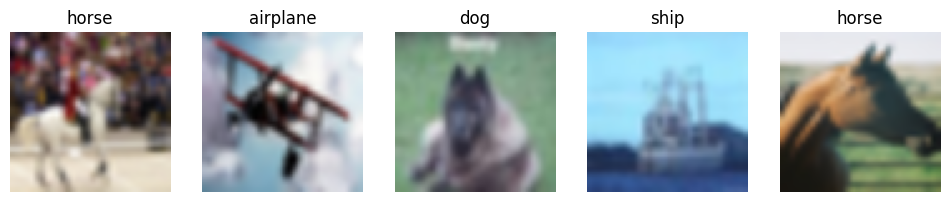

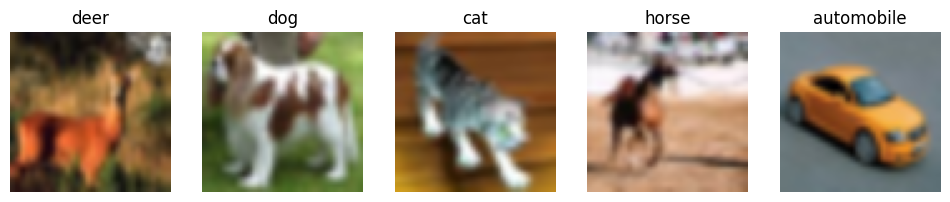

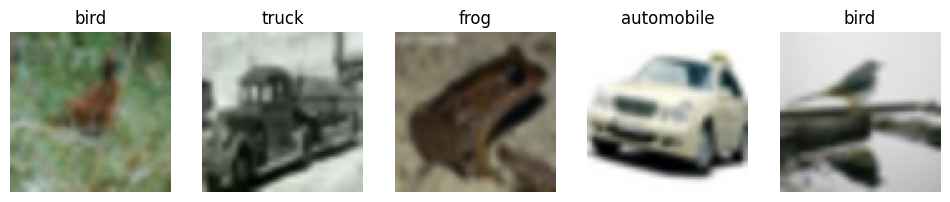

In [74]:
for k in range(3):
  sel = np.random.randint(0,X_train.shape[0],size = 5)
  k = 2
  fig, ax = plt.subplots(nrows=1,ncols=len(sel), figsize=(12,4))
  for i,s in enumerate(sel):
    ax[i].imshow(cv.resize(X_train[s].reshape(32,32,3), (32*k, 32*k)))
    ax[i].set_title(label[y_train[s,0]])
    ax[i].set_axis_off()

In [75]:
def ffnn(n_inputs, hidden, n_outputs):
  model = tf.keras.models.Sequential()
  model.add(Input((n_inputs,)))
  for h in hidden:
    model.add(Dense(h,activation='relu'))
  model.add(Dense(n_outputs,activation='softmax'))
  return model

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_25 (Dense)                │ (None, 256)            │       786,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,052,170 (4.01 MB)

 Trainable params: 1,052,170 (4.01 MB)

 Non-trainable params: 0 (0.00 B)

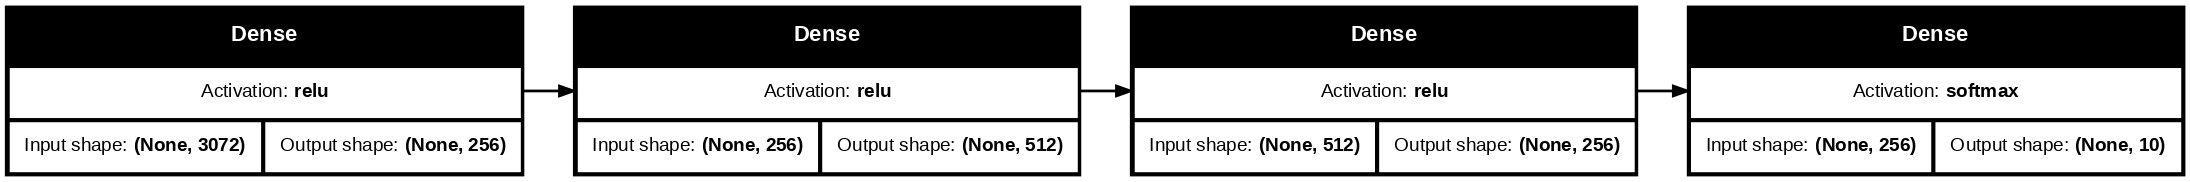

In [76]:
model = ffnn(X_train.shape[1],[256,512,256],y_train_oh.shape[1])
model.summary()

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss="categorical_crossentropy", metrics=["accuracy"])
plot_model(model, show_shapes=True, show_layer_names=False, show_layer_activations=True,rankdir='LR',dpi=100)

Epoch 1/20
100/100 - 10s - 96ms/step - accuracy: 0.3025 - loss: 1.9251 - val_accuracy: 0.3819 - val_loss: 1.7303
Epoch 2/20
100/100 - 6s - 64ms/step - accuracy: 0.3966 - loss: 1.6830 - val_accuracy: 0.4125 - val_loss: 1.6322
Epoch 3/20
100/100 - 10s - 103ms/step - accuracy: 0.4310 - loss: 1.5912 - val_accuracy: 0.4464 - val_loss: 1.5464
Epoch 4/20
100/100 - 8s - 80ms/step - accuracy: 0.4571 - loss: 1.5262 - val_accuracy: 0.4518 - val_loss: 1.5259
Epoch 5/20
100/100 - 6s - 64ms/step - accuracy: 0.4738 - loss: 1.4784 - val_accuracy: 0.4563 - val_loss: 1.5310
Epoch 6/20
100/100 - 8s - 80ms/step - accuracy: 0.4844 - loss: 1.4506 - val_accuracy: 0.4832 - val_loss: 1.4554
Epoch 7/20
100/100 - 6s - 63ms/step - accuracy: 0.5005 - loss: 1.4055 - val_accuracy: 0.4887 - val_loss: 1.4312
Epoch 8/20
100/100 - 8s - 80ms/step - accuracy: 0.5117 - loss: 1.3751 - val_accuracy: 0.4936 - val_loss: 1.4214
Epoch 9/20
100/100 - 6s - 63ms/step - accuracy: 0.5153 - loss: 1.3644 - val_accuracy: 0.4866 - val_lo

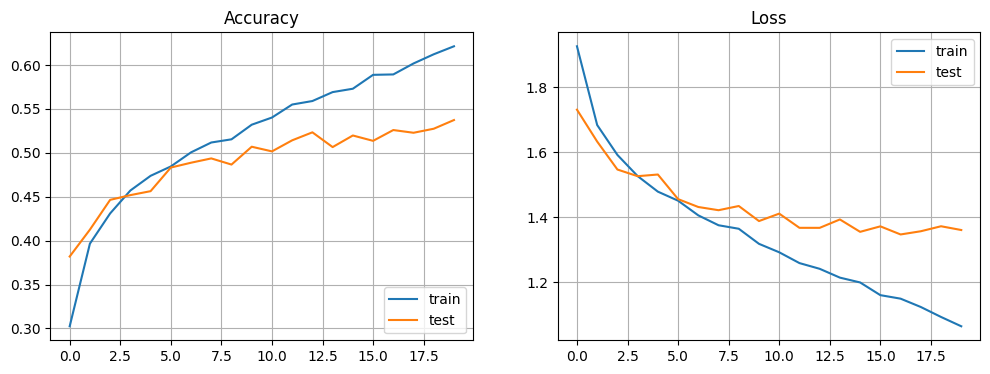

In [77]:
start_train = time.time()
history = model.fit(
    X_train, y_train_oh,
    epochs = 20,
    batch_size = 500,
    verbose = 2,
    validation_data=(X_test, y_test_oh),
)
end_train = time.time()
plot_results(history)
pred = model.predict(X_test)
print('Elapsed time training= {:.4f} secs'.format(end_train-start_train))
pred_int = np.argmax(pred,axis=1)
print('Accuracy = {:.4f}'.format(accuracy_score(y_test,np.argmax(pred,axis=1))))

## CIFAR-10 Convolutional Classification

In [78]:
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.cifar10.load_data()
# Convert from uint8 to float and scale in [0,1] range
X_train = np.float32(X_train/255.0)
X_test = np.float32(X_test/255.0)

In [79]:
print(f'{X_train.shape=}')
print(f'{X_test.shape=}')
print(f'{y_train.shape=}')
print(f'{y_test.shape=}')

X_train.shape=(50000, 32, 32, 3)
X_test.shape=(10000, 32, 32, 3)
y_train.shape=(50000, 1)
y_test.shape=(10000, 1)


In [80]:
y_train_oh = tf.keras.utils.to_categorical(y_train, 10)
y_test_oh = tf.keras.utils.to_categorical(y_test, 10)

In [81]:
def cnn(input_shape, conv_units,dense_units,out_units):
  model = tf.keras.Sequential()
  model.add(Input(shape=input_shape))
  model.add(Conv2D(conv_units, kernel_size=(3, 3),  activation="relu"))
  model.add(MaxPooling2D(pool_size=(2, 2)))
  model.add(Flatten())
  model.add(Dense(dense_units, activation='relu'))
  model.add(Dense(out_units, activation='softmax'))
  return model

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_7 (Conv2D)               │ (None, 30, 30, 50)     │         1,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 15, 15, 50)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 11250)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 100)            │     1,125,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,127,510 (4.30 MB)

 Trainable params: 1,127,510 (4.30 MB)

 Non-trainable params: 0 (0.00 B)

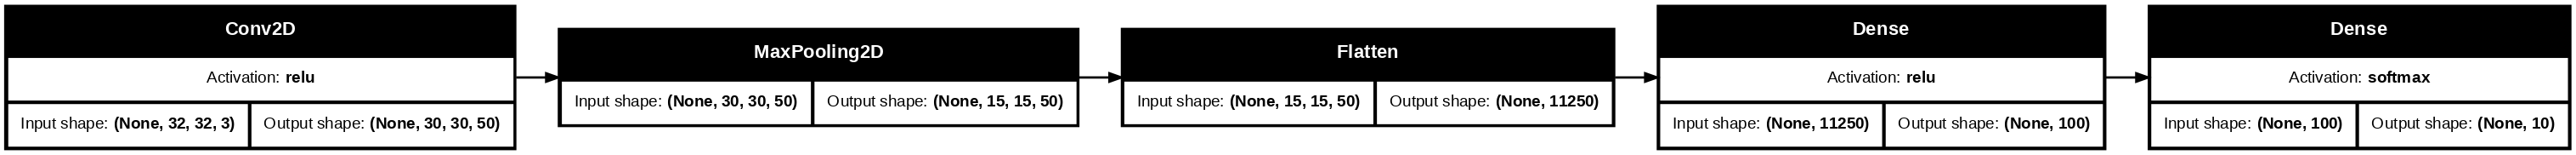

In [82]:
model = cnn(X_train.shape[1:],50,100,y_train_oh.shape[1])
model.summary()

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss="categorical_crossentropy", metrics=["accuracy"])
plot_model(model, show_shapes=True, show_layer_names=False, show_layer_activations=True,rankdir='LR',dpi=100)

Epoch 1/20
100/100 - 64s - 641ms/step - accuracy: 0.3700 - loss: 1.7933 - val_accuracy: 0.4607 - val_loss: 1.5554
Epoch 2/20
100/100 - 80s - 800ms/step - accuracy: 0.5074 - loss: 1.4121 - val_accuracy: 0.5320 - val_loss: 1.3488
Epoch 3/20
100/100 - 107s - 1s/step - accuracy: 0.5509 - loss: 1.2883 - val_accuracy: 0.5573 - val_loss: 1.2589
Epoch 4/20
100/100 - 120s - 1s/step - accuracy: 0.5834 - loss: 1.1996 - val_accuracy: 0.5738 - val_loss: 1.2119
Epoch 5/20
100/100 - 63s - 628ms/step - accuracy: 0.5986 - loss: 1.1539 - val_accuracy: 0.5757 - val_loss: 1.1877
Epoch 6/20
100/100 - 81s - 813ms/step - accuracy: 0.6195 - loss: 1.1008 - val_accuracy: 0.5954 - val_loss: 1.1493
Epoch 7/20
100/100 - 82s - 824ms/step - accuracy: 0.6342 - loss: 1.0617 - val_accuracy: 0.6011 - val_loss: 1.1406
Epoch 8/20
100/100 - 82s - 818ms/step - accuracy: 0.6498 - loss: 1.0207 - val_accuracy: 0.6222 - val_loss: 1.0833
Epoch 9/20
100/100 - 62s - 616ms/step - accuracy: 0.6644 - loss: 0.9790 - val_accuracy: 0.62

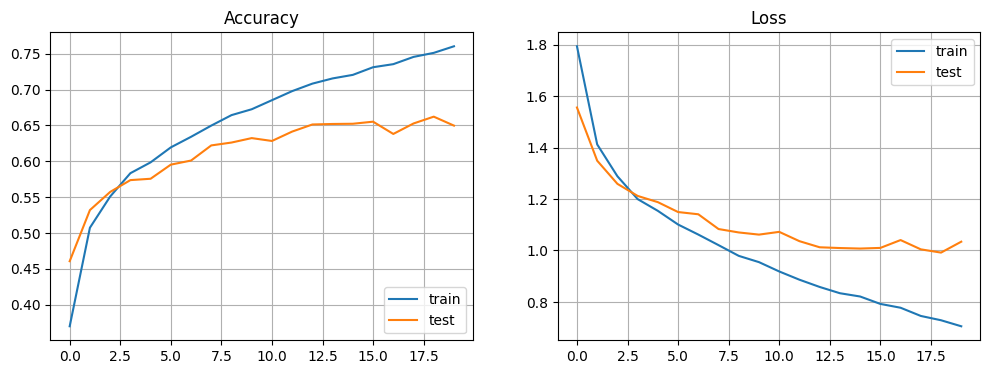

In [83]:
start_train = time.time()
history = model.fit(
    X_train, y_train_oh,
    epochs = 20,
    batch_size = 500,
    verbose = 2,
    validation_data=(X_test, y_test_oh),
)
end_train = time.time()
plot_results(history)
pred = model.predict(X_test)
print('Elapsed time training= {:.4f} secs'.format(end_train-start_train))
pred_int = np.argmax(pred,axis=1)
print('Accuracy = {:.4f}'.format(accuracy_score(y_test,np.argmax(pred,axis=1))))

In [84]:
def cnn(input_shape, conv_units,dense_units,out_units):
  model = tf.keras.Sequential()
  model.add(Input(shape=input_shape))
  for c in conv_units:
    model.add(Conv2D(c, kernel_size=(3, 3),  activation="relu"))
    model.add(MaxPooling2D(pool_size=(2, 2)))
  model.add(Flatten())
  model.add(Dense(dense_units, activation='relu'))
  model.add(Dense(out_units, activation='softmax'))
  return model

Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 30, 30, 50)     │         1,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 15, 15, 50)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 13, 13, 100)    │        45,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 6, 6, 100)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 4, 4, 200)      │       180,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 2, 2, 200)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 800)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 100)            │        80,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 307,810 (1.17 MB)

 Trainable params: 307,810 (1.17 MB)

 Non-trainable params: 0 (0.00 B)

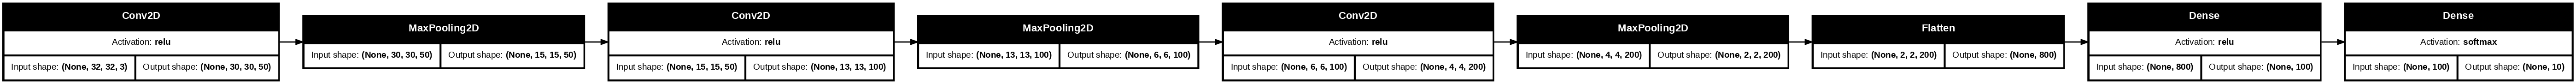

In [85]:
model = cnn(X_train.shape[1:],[50,100,200],100,y_train_oh.shape[1])
model.summary()

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss="categorical_crossentropy", metrics=["accuracy"])
plot_model(model, show_shapes=True, show_layer_names=False, show_layer_activations=True,rankdir='LR',dpi=100)

Epoch 1/20
100/100 - 160s - 2s/step - accuracy: 0.3250 - loss: 1.8534 - val_accuracy: 0.4198 - val_loss: 1.5817
Epoch 2/20
100/100 - 201s - 2s/step - accuracy: 0.4649 - loss: 1.4689 - val_accuracy: 0.4961 - val_loss: 1.4105
Epoch 3/20
100/100 - 207s - 2s/step - accuracy: 0.5276 - loss: 1.3181 - val_accuracy: 0.5522 - val_loss: 1.2484
Epoch 4/20
100/100 - 171s - 2s/step - accuracy: 0.5696 - loss: 1.2155 - val_accuracy: 0.5780 - val_loss: 1.1853
Epoch 5/20
100/100 - 170s - 2s/step - accuracy: 0.6004 - loss: 1.1361 - val_accuracy: 0.6000 - val_loss: 1.1144
Epoch 6/20
100/100 - 161s - 2s/step - accuracy: 0.6225 - loss: 1.0754 - val_accuracy: 0.6144 - val_loss: 1.0947
Epoch 7/20
100/100 - 163s - 2s/step - accuracy: 0.6433 - loss: 1.0197 - val_accuracy: 0.6273 - val_loss: 1.0672
Epoch 8/20
100/100 - 161s - 2s/step - accuracy: 0.6615 - loss: 0.9704 - val_accuracy: 0.6501 - val_loss: 0.9996
Epoch 9/20
100/100 - 160s - 2s/step - accuracy: 0.6760 - loss: 0.9285 - val_accuracy: 0.6558 - val_loss:

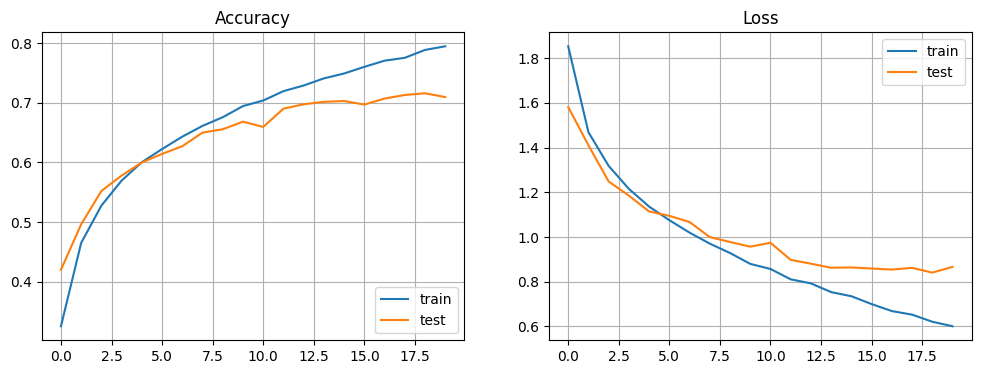

In [86]:
start_train = time.time()
history = model.fit(
    X_train, y_train_oh,
    epochs = 20,
    batch_size = 500,
    verbose = 2,
    validation_data=(X_test, y_test_oh),
)
end_train = time.time()
plot_results(history)
pred = model.predict(X_test)
print('Elapsed time training= {:.4f} secs'.format(end_train-start_train))
pred_int = np.argmax(pred,axis=1)
print('Accuracy = {:.4f}'.format(accuracy_score(y_test,np.argmax(pred,axis=1))))

## CIFAR-10 CNN and Feature-Order Sensitivity

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv
import tensorflow as tf
from tensorflow.keras.layers import *
from tensorflow.keras.losses import *
from tensorflow.keras.activations import *
from keras.utils import plot_model

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix,mean_squared_error,mean_absolute_error

import time

In [10]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()
# Convert from uint8 to float and scale in [0,1] range
x_train = np.float32(x_train/255.0)
x_test = np.float32(x_test/255.0)
label = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']

# Convert y to one-hot
y_train = tf.keras.utils.to_categorical(y_train, 10)
y_test = tf.keras.utils.to_categorical(y_test, 10)

print('Final shapes')
print(f'{x_train.shape = }')
print(f'{y_train.shape = }')
print(f'{x_test.shape = }')
print(f'{y_test.shape = }')

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1074s 6us/step
Final shapes
x_train.shape = (50000, 32, 32, 3)
y_train.shape = (50000, 10)
x_test.shape = (10000, 32, 32, 3)
y_test.shape = (10000, 10)


In [11]:
def plot_results(history):
  fig, ax = plt.subplots(ncols=2, figsize=(12,4))
  ax[0].plot(history.history['accuracy'],label = 'train')
  ax[0].plot(history.history['val_accuracy'],label = 'test')
  ax[0].set_title('Accuracy')
  ax[0].legend(loc='lower right')
  ax[1].plot(history.history['loss'],label = 'train')
  ax[1].plot(history.history['val_loss'],label = 'test')
  ax[1].set_title('Loss')
  ax[1].legend(loc='upper right')
  plt.show()

def print_best_metrics(h):
  labels = ['training accuracy', 'validation accuracy', 'training loss', 'validation loss']
  keys = ['accuracy', 'val_accuracy', 'loss', 'val_loss']
  prefix = ['highest','lowest']
  for i in range(4):
    metric = np.array(h[keys[i]])
    am = np.argmax((1.5-i)*metric)
    print(f'The {prefix[i//2]} {labels[i]} was {metric[am]:.4f} obtained in epoch {am+1}')
    print(f'The final {labels[i]} was {metric[-1]:.4f}')

Let's see some of the images in the dataset

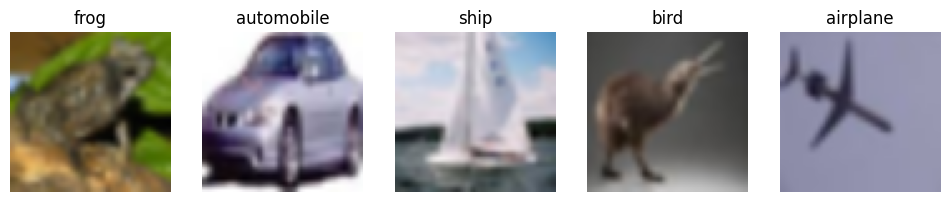

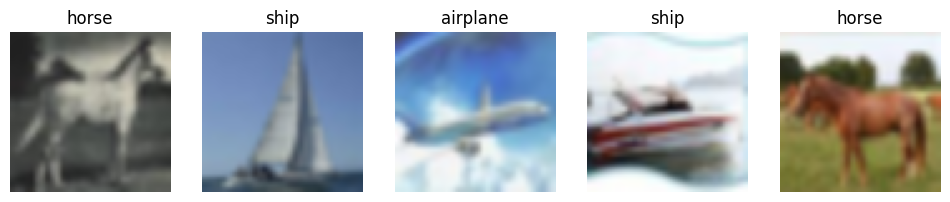

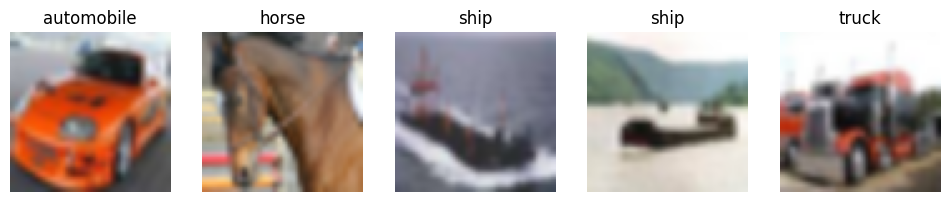

In [12]:
for k in range(3):
  sel = np.random.randint(0,x_train.shape[0],size = 5)
  k = 2
  fig, ax = plt.subplots(nrows=1,ncols=len(sel), figsize=(12,4))
  for i,s in enumerate(sel):
    ax[i].imshow(cv.resize(x_train[s], (32*k, 32*k)))
    ax[i].set_title(label[np.argmax(y_train[s])])
    ax[i].set_axis_off()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 48)     │        13,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 48)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 64)       │        27,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 108,730 (424.73 KB)

 Trainable params: 108,730 (424.73 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
500/500 - 8s - 17ms/step - accuracy: 0.4348 - loss: 1.5586 - val_accuracy: 0.5424 - val_loss: 1.2856
Epoch 2/20
500/500 - 3s - 6ms/step - accuracy: 0.5770 - loss: 1.1993 - val_accuracy: 0.6107 - val_loss: 1.1035
Epoch 3/20
500/500 - 3s - 6ms/step - accuracy: 0.6384 - loss: 1.0323 - val_accuracy: 0.6479 - val_loss: 1.0031
Epoch 4/20
500/500 - 3s - 6ms/step - accuracy: 0.6767 - loss: 0.9248 - val_accuracy: 0.6686 - val_loss: 0.9609
Epoch 5/20
500/500 - 3s - 6ms/step - accuracy: 0.7021 - loss: 0.8527 - val_accuracy: 0.6889 - val_loss: 0.8985
Epoch 6/20
500/500 - 3s - 6ms/step - accuracy: 0.7229 - loss: 0.7957 - val_accuracy: 0.6926 - val_loss: 0.8967
Epoch 7/20
500/500 - 3s - 6ms/step - accuracy: 0.7398 - loss: 0.7493 - val_accuracy: 0.7006 - val_loss: 0.8836
Epoch 8/20
500/500 - 3s - 5ms/step - accuracy: 0.7549 - loss: 0.7038 - val_accuracy: 0.7155 - val_loss: 0.8311
Epoch 9/20
500/500 - 3s - 5ms/step - accuracy: 0.7709 - loss: 0.6594 - val_accuracy: 0.7196 - val_loss: 0.8281


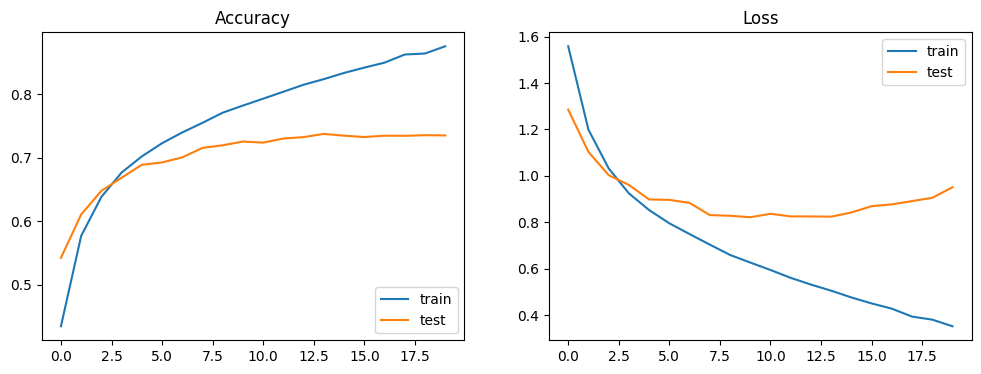

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
Elapsed time training= 65.6240 secs
Mean squared error = 0.040
Accuracy = 0.7351
The highest training accuracy was 0.8754 obtained in epoch 20
The final training accuracy was 0.8754
The highest validation accuracy was 0.7375 obtained in epoch 14
The final validation accuracy was 0.7351
The lowest training loss was 0.3518 obtained in epoch 20
The final training loss was 0.3518
The lowest validation loss was 0.8218 obtained in epoch 10
The final validation loss was 0.9511


In [13]:
def cnn(input_shape, conv_units,dense_units):
  model = tf.keras.Sequential()
  model.add(Input(shape=input_shape))
  for c in conv_units:
    model.add(Conv2D(c, kernel_size=(3, 3),  padding='same', activation="relu"))
    model.add(MaxPooling2D(pool_size=(2, 2)))
  model.add(Flatten())
  model.add(Dense(dense_units, activation='relu'))
  model.add(Dense(10, activation='softmax'))
  return model

model = cnn(x_train.shape[1:],[32,48,64],64)
model.summary()
model.compile(optimizer=tf.keras.optimizers.Adam(),loss="CategoricalCrossentropy", metrics=["accuracy"])
plot_model(model, show_shapes=True, show_layer_names=False, show_layer_activations=True)

start_train = time.time()
history = model.fit(
    x_train, y_train,
    epochs = 20,
    batch_size = 100,
    verbose = 2,
    validation_data=(x_test, y_test),
)
end_train = time.time()
plot_results(history)
pred = model.predict(x_test)
print('Elapsed time training= {:.4f} secs'.format(end_train-start_train))
print('Mean squared error = {:5.3f}'.format(mean_squared_error(pred,y_test)))
pred_int = np.argmax(pred,axis=1)
print('Accuracy = {:.4f}'.format(accuracy_score(np.argmax(y_test,axis=1),np.argmax(pred,axis=1))))
print_best_metrics(history.history)

In [92]:
pred[0]

array([6.8076071e-04, 3.1717917e-07, 8.7364815e-06, 7.9173571e-01,
       7.0574803e-05, 2.0671169e-01, 1.1718280e-04, 8.0857331e-05,
       5.9292070e-04, 1.3256383e-06], dtype=float32)

## Feature-Order Sensitivity

Since the network treats each of the 3072 attributes independently, if we shuffle the columns in the training data, we expect to see the same performance. Let's see if this is the case.

In [14]:
ind = np.random.permutation(x_train.shape[1])
x_train = x_train.reshape(x_train.shape[0],-1)
x_test = x_test.reshape(x_test.shape[0],-1)
ind = np.random.permutation(x_train.shape[1])
x_train = x_train[:,ind]
x_test = x_test[:,ind]
x_train = x_train.reshape((x_train.shape[0],32,32,3))
x_test = x_test.reshape((x_test.shape[0],32,32,3))

Now let's see the resulting images.

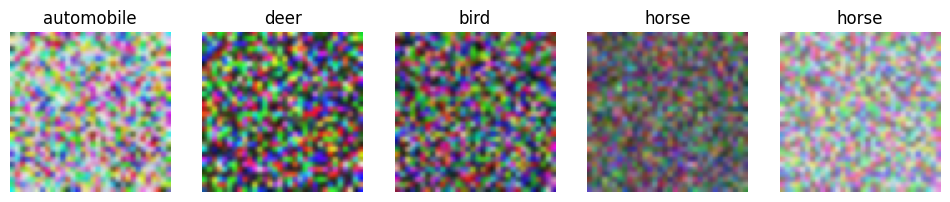

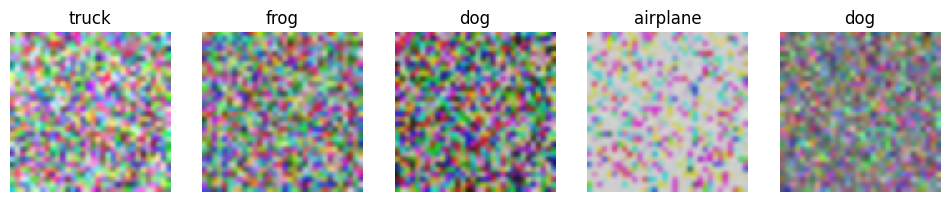

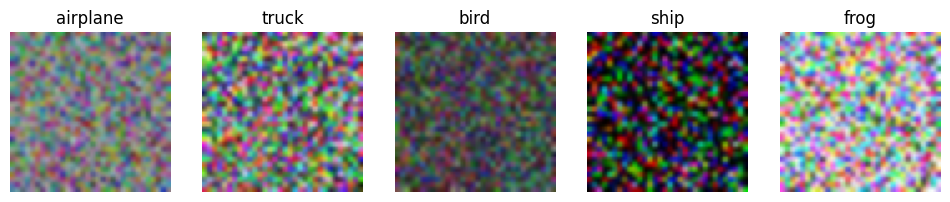

In [94]:
for k in range(3):
  sel = np.random.randint(0,x_train.shape[0],size = 5)
  k = 2
  fig, ax = plt.subplots(nrows=1,ncols=len(sel), figsize=(12,4))
  for i,s in enumerate(sel):
    ax[i].imshow(cv.resize(x_train[s].reshape(32,32,3), (32*k, 32*k)))
    ax[i].set_title(label[np.argmax(y_train[s])])
    ax[i].set_axis_off()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 48)     │        13,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 8, 8, 48)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 64)       │        27,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 108,730 (424.73 KB)

 Trainable params: 108,730 (424.73 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
500/500 - 7s - 14ms/step - accuracy: 0.2803 - loss: 1.9580 - val_accuracy: 0.3842 - val_loss: 1.7226
Epoch 2/20
500/500 - 3s - 5ms/step - accuracy: 0.4127 - loss: 1.6363 - val_accuracy: 0.4346 - val_loss: 1.5688
Epoch 3/20
500/500 - 3s - 5ms/step - accuracy: 0.4569 - loss: 1.5154 - val_accuracy: 0.4615 - val_loss: 1.5103
Epoch 4/20
500/500 - 6s - 11ms/step - accuracy: 0.4853 - loss: 1.4365 - val_accuracy: 0.4658 - val_loss: 1.4874
Epoch 5/20
500/500 - 3s - 6ms/step - accuracy: 0.5071 - loss: 1.3740 - val_accuracy: 0.4763 - val_loss: 1.4805
Epoch 6/20
500/500 - 3s - 6ms/step - accuracy: 0.5302 - loss: 1.3176 - val_accuracy: 0.4814 - val_loss: 1.4627
Epoch 7/20
500/500 - 3s - 5ms/step - accuracy: 0.5510 - loss: 1.2676 - val_accuracy: 0.4797 - val_loss: 1.4604
Epoch 8/20
500/500 - 3s - 6ms/step - accuracy: 0.5634 - loss: 1.2231 - val_accuracy: 0.4754 - val_loss: 1.5246
Epoch 9/20
500/500 - 3s - 6ms/step - accuracy: 0.5804 - loss: 1.1798 - val_accuracy: 0.4802 - val_loss: 1.4753

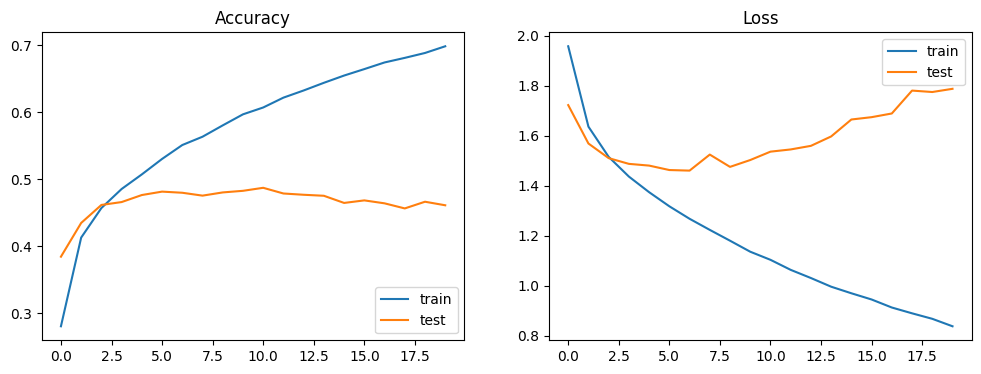

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Elapsed time training= 68.6782 secs
Mean squared error = 0.073
Accuracy = 0.4610
The highest training accuracy was 0.6985 obtained in epoch 20
The final training accuracy was 0.6985
The highest validation accuracy was 0.4871 obtained in epoch 11
The final validation accuracy was 0.4610
The lowest training loss was 0.8373 obtained in epoch 20
The final training loss was 0.8373
The lowest validation loss was 1.4604 obtained in epoch 7
The final validation loss was 1.7878


In [15]:
def cnn(input_shape, conv_units,dense_units):
  model = tf.keras.Sequential()
  model.add(Input(shape=input_shape))
  for c in conv_units:
    model.add(Conv2D(c, kernel_size=(3, 3),  padding='same', activation="relu"))
    model.add(MaxPooling2D(pool_size=(2, 2)))
  model.add(Flatten())
  model.add(Dense(dense_units, activation='relu'))
  model.add(Dense(10, activation='softmax'))
  return model

model = cnn(x_train.shape[1:],[32,48,64],64)
model.summary()
model.compile(optimizer=tf.keras.optimizers.Adam(),loss="CategoricalCrossentropy", metrics=["accuracy"])
plot_model(model, show_shapes=True, show_layer_names=False, show_layer_activations=True)

start_train = time.time()
history = model.fit(
    x_train, y_train,
    epochs = 20,
    batch_size = 100,
    verbose = 2,
    validation_data=(x_test, y_test),
)
end_train = time.time()
plot_results(history)
pred = model.predict(x_test)
print('Elapsed time training= {:.4f} secs'.format(end_train-start_train))
print('Mean squared error = {:5.3f}'.format(mean_squared_error(pred,y_test)))
pred_int = np.argmax(pred,axis=1)
print('Accuracy = {:.4f}'.format(accuracy_score(np.argmax(y_test,axis=1),np.argmax(pred,axis=1))))
print_best_metrics(history.history)

As expected, performance is much worse than with the original data. In fact, it is worse than the performance of the dense network on the same data.